<a href="https://colab.research.google.com/github/Leonanda1013/DataLoverz/blob/main/Competition/FindIT/Ensemble_Efficientnet_ViT_Convnext.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set Up

In [ ]:
!pip install ultralytics

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

# gunakan model ringan dulu
yolo_model = YOLO("yolov8n.pt")

import cv2
import numpy as np
import os
from tqdm import tqdm

from sklearn.model_selection import train_test_split

import torchvision.transforms as T

from torch.utils.data import DataLoader
import torch
import torchvision
from torch.utils.data import Dataset
from PIL import Image

import torch.nn as nn
import timm



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load Dataset

In [ ]:

def load_train_dataset(train_path, limit=None):
    """
    Load dataset train (multiclass folder)

    Parameter:
        train_path: path ke folder train
        limit: max gambar per class (None = semua)

    Return:
        image_paths: list path gambar
        labels: list label_id
        label_to_id: mapping label -> int
    """

    train_path = Path(train_path)

    class_dirs = sorted([d for d in train_path.iterdir() if d.is_dir()])

    label_to_id = {cls.name: idx for idx, cls in enumerate(class_dirs)}

    image_paths = []
    labels = []

    for cls in class_dirs:
        label_name = cls.name
        label_id = label_to_id[label_name]

        image_files = (
            list(cls.glob("*.jpg")) +
            list(cls.glob("*.png")) +
            list(cls.glob("*.jpeg"))
        )

        if limit:
            image_files = image_files[:limit]

        for img_path in image_files:
            image_paths.append(str(img_path))
            labels.append(label_id)

    return image_paths, labels, label_to_id

In [ ]:
def load_test_dataset(test_path):
    """
    Load dataset test (tanpa label)

    Parameter:
        test_path: path ke folder test

    Return:
        image_paths: list path gambar
        image_ids: nama file (untuk submission)
    """

    test_path = Path(test_path)

    image_files = (
        list(test_path.glob("*.jpg")) +
        list(test_path.glob("*.png")) +
        list(test_path.glob("*.jpeg"))
    )

    image_paths = [str(p) for p in image_files]
    image_ids = [p.stem for p in image_files]  # nama tanpa extension

    return image_paths, image_ids

In [ ]:

def build_train_df(image_paths, labels):
    return pd.DataFrame({
        "path": image_paths,
        "label": labels
    })

def build_test_df(image_paths, image_ids):
    return pd.DataFrame({
        "path": image_paths,
        "id": image_ids
    })

coba

In [ ]:
train_paths, train_labels, label_map = load_train_dataset(
    train_path="/content/drive/MyDrive/DATASET/data-analytics-competition-dac-find-it-2026/train",
    limit=None
)

test_paths, test_ids = load_test_dataset(
    test_path="/content/drive/MyDrive/DATASET/data-analytics-competition-dac-find-it-2026/test"
)

train_df = build_train_df(train_paths, train_labels)
test_df  = build_test_df(test_paths, test_ids)

print(label_map)
print(train_df.head())
print(test_df.head())

{'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}
                                                path  label
0  /content/drive/MyDrive/DATASET/data-analytics-...      0
1  /content/drive/MyDrive/DATASET/data-analytics-...      0
2  /content/drive/MyDrive/DATASET/data-analytics-...      0
3  /content/drive/MyDrive/DATASET/data-analytics-...      0
4  /content/drive/MyDrive/DATASET/data-analytics-...      0
                                                path        id
0  /content/drive/MyDrive/DATASET/data-analytics-...  test_004
1  /content/drive/MyDrive/DATASET/data-analytics-...  test_005
2  /content/drive/MyDrive/DATASET/data-analytics-...  test_003
3  /content/drive/MyDrive/DATASET/data-analytics-...  test_001
4  /content/drive/MyDrive/DATASET/data-analytics-...  test_008


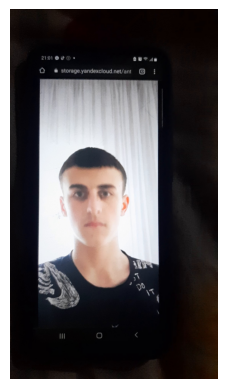

In [ ]:

def show_image(path):
    img = Image.open(path).convert("RGB")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# contoh
show_image(train_df.loc[700, "path"])

In [ ]:
train_df.tail(700)

,path,label
738,/content/drive/MyDrive/DATASET/data-analytics-...,4
739,/content/drive/MyDrive/DATASET/data-analytics-...,4
740,/content/drive/MyDrive/DATASET/data-analytics-...,4
741,/content/drive/MyDrive/DATASET/data-analytics-...,4
742,/content/drive/MyDrive/DATASET/data-analytics-...,4
...,...,...
1433,/content/drive/MyDrive/DATASET/data-analytics-...,5
1434,/content/drive/MyDrive/DATASET/data-analytics-...,5
1435,/content/drive/MyDrive/DATASET/data-analytics-...,5
1436,/content/drive/MyDrive/DATASET/data-analytics-...,5


# Deteksi Wajah

In [ ]:
def detect_and_crop_face(
    image_path,
    model,
    conf=0.3,
    pad=0.1,
    target_size=None,
    fallback=True
):
    """
    Detect dan crop wajah dari gambar

    Parameter:
        image_path: path gambar
        model: YOLO model
        conf: confidence threshold
        pad: margin bbox (0.1 = 10%)
        target_size: resize (misal (224,224))
        fallback: jika gagal detect, pakai full image

    Return:
        cropped_face (numpy array)
    """

    img = cv2.imread(image_path)
    h, w, _ = img.shape

    results = model(img, conf=conf, verbose=False)[0]

    # tidak ada deteksi
    if len(results.boxes) == 0:
        if fallback:
            face = img
        else:
            return None
    else:
        # ambil bbox terbesar (best practice untuk face)
        boxes = results.boxes.xyxy.cpu().numpy()

        areas = (boxes[:,2] - boxes[:,0]) * (boxes[:,3] - boxes[:,1])
        idx = np.argmax(areas)

        x1, y1, x2, y2 = boxes[idx]

        # tambah padding
        bw = x2 - x1
        bh = y2 - y1

        x1 = int(max(0, x1 - pad * bw))
        y1 = int(max(0, y1 - pad * bh))
        x2 = int(min(w, x2 + pad * bw))
        y2 = int(min(h, y2 + pad * bh))

        face = img[y1:y2, x1:x2]

    # resize opsional
    if target_size:
        face = cv2.resize(face, target_size)

    return face

In [ ]:
def process_dataset(df, save_dir, model):
    os.makedirs(save_dir, exist_ok=True)

    new_paths = []

    for i, row in tqdm(df.iterrows(), total=len(df)):
        img_path = row["path"]

        face = detect_and_crop_face(
            img_path,
            model=model,
            pad=0.15,
            target_size=(224,224)
        )

        save_path = os.path.join(save_dir, f"{i}.jpg")
        cv2.imwrite(save_path, face)

        new_paths.append(save_path)

    df["face_path"] = new_paths
    return df

coba

In [ ]:
train_df = process_dataset(
    train_df,
    save_dir="/content/drive/MyDrive/faces/train",
    model=yolo_model
)

100%|██████████| 1438/1438 [06:52<00:00,  3.49it/s]


In [ ]:
rain_df.head()

,path,label,face_path
0,/content/drive/MyDrive/DATASET/data-analytics-...,0,/content/drive/MyDrive/faces/train/0.jpg
1,/content/drive/MyDrive/DATASET/data-analytics-...,0,/content/drive/MyDrive/faces/train/1.jpg
2,/content/drive/MyDrive/DATASET/data-analytics-...,0,/content/drive/MyDrive/faces/train/2.jpg
3,/content/drive/MyDrive/DATASET/data-analytics-...,0,/content/drive/MyDrive/faces/train/3.jpg
4,/content/drive/MyDrive/DATASET/data-analytics-...,0,/content/drive/MyDrive/faces/train/4.jpg


# Augmentasi

In [ ]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],  # penting biar balance
    random_state=42
)

In [ ]:
train_tf = T.Compose([
    T.Resize((224,224)),

    # spatial
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),

    # photometric
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.05
    ),

    # noise
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

    T.ToTensor(),  # ← koma di sini
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),  # ← koma di sini
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class FaceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["face_path"]).convert("RGB")
        label = row["label"]

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
train_ds = FaceDataset(train_df, transform=train_tf)
val_ds   = FaceDataset(val_df, transform=val_tf)

In [ ]:
print(len(train_df), len(val_df))
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())

1150 288
label
5    327
4    238
1    201
0    157
3    150
2     77
Name: count, dtype: int64
label
5    82
4    60
1    50
0    39
3    38
2    19
Name: count, dtype: int64


data louder

In [ ]:
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=False
)

# modelling

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=6
).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
import torch.optim as optim

optimizer = optim.AdamW(model.parameters(), lr=1e-4)

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def validate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss / len(loader), acc

In [ ]:
epochs = 10

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


In [ ]:
best_acc = 0
if val_acc > best_acc:
    best_acc = val_acc
    torch.save(model.state_dict(), "best_model.pth")

# To Submit

In [ ]:
import torch
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=6
)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
model.eval()

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [ ]:
import torchvision.transforms as T

test_tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class TestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["face_path"]).convert("RGB")
        img_id = row["id"]

        if self.transform:
            img = self.transform(img)

        return img, img_id

In [ ]:
test_df = process_dataset(
    test_df,
    save_dir="/content/drive/MyDrive/faces/test",
    model=yolo_model
)

100%|██████████| 404/404 [01:50<00:00,  3.66it/s]


In [ ]:
test_ds = TestDataset(test_df, transform=test_tf)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [ ]:
print(test_df.columns)

Index(['path', 'id', 'face_path'], dtype='object')


In [ ]:
row = test_df.iloc[0]
img = Image.open(row["face_path"]).convert("RGB")

In [ ]:
import numpy as np

preds = []
ids = []

with torch.no_grad():
    for imgs, img_ids in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        pred = outputs.argmax(1).cpu().numpy()

        preds.extend(pred)
        ids.extend(img_ids)

In [ ]:
print(len(preds), len(ids), len(test_df))
print(set(preds))  # harus 0–5

In [ ]:
id_to_label = {v: k for k, v in label_map.items()}
pred_labels = [id_to_label[p] for p in preds]

In [ ]:
import pandas as pd

submission = pd.DataFrame({
    "id": ids,
    "label": pred_labels
})
submission = submission.sort_values(by="id").reset_index(drop=True)

submission.to_csv("submission.csv", index=False)

In [ ]:
print(submission.head())
print(submission.shape)

In [ ]:
submission.tail()

# Cek Ground Truth

In [ ]:
import pandas as pd

sub = pd.read_csv("/content/submission_ensemble.csv")      # hasil prediksi
gt  = pd.read_csv("/content/drive/MyDrive/DATASET/ground_truth.csv")    # label benar

In [ ]:
print(sub.head())
print(gt.head())

In [ ]:
gt = gt[['id', 'label']]

In [ ]:
df_eval = sub.merge(gt, on="id", suffixes=("_pred", "_true"))

In [ ]:
acc = (df_eval["label_pred"] == df_eval["label_true"]).mean()
print("Accuracy:", acc)

Accuracy: 0.8985148514851485


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df_eval["label_true"],
    df_eval["label_pred"]
)

print(cm)

[[45  0  0  0  0  0]
 [ 5 62  0  0  2  1]
 [ 1  0 54  1  2  5]
 [ 0  3  2 61  3  4]
 [ 2  0  0  0 47  0]
 [ 0  7  0  2  1 94]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    df_eval["label_true"],
    df_eval["label_pred"]
))

                precision    recall  f1-score   support

fake_mannequin       0.85      1.00      0.92        45
     fake_mask       0.86      0.89      0.87        70
  fake_printed       0.96      0.86      0.91        63
   fake_screen       0.95      0.84      0.89        73
  fake_unknown       0.85      0.96      0.90        49
    realperson       0.90      0.90      0.90       104

      accuracy                           0.90       404
     macro avg       0.90      0.91      0.90       404
  weighted avg       0.90      0.90      0.90       404



In [ ]:
wrong = df_eval[df_eval["label_pred"] != df_eval["label_true"]]
print(wrong.head())
print(wrong.shape)
wrong.to_csv("wrong.csv", index=False)

          id    label_pred    label_true
6   test_007     fake_mask    realperson
13  test_014  fake_printed   fake_screen
16  test_017  fake_unknown     fake_mask
23  test_024  fake_unknown   fake_screen
27  test_028    realperson  fake_printed
(41, 3)


# Coba Model Lain

In [ ]:
import torch
import torch.nn as nn
import timm

def train_convnext(
    train_loader,
    val_loader,
    device,
    num_classes=6,
    epochs=10,
    lr=1e-4
):
    model = timm.create_model(
        "convnext_tiny",
        pretrained=True,
        num_classes=num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc = 0

    for epoch in range(epochs):
        print(f"\n[ConvNeXt] Epoch {epoch+1}")

        # ===== TRAIN =====
        model.train()
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                pred = outputs.argmax(1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        print(f"Train Loss: {train_loss/len(train_loader):.4f}")
        print(f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f}")

        # save best
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "convnext_best.pth")

        scheduler.step()

    return model

In [ ]:
def train_vit(
    train_loader,
    val_loader,
    device,
    num_classes=6,
    epochs=10,
    lr=3e-5   # ViT biasanya lebih kecil
):
    model = timm.create_model(
        "vit_base_patch16_224",
        pretrained=True,
        num_classes=num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc = 0

    for epoch in range(epochs):
        print(f"\n[ViT] Epoch {epoch+1}")

        # ===== TRAIN =====
        model.train()
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                pred = outputs.argmax(1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        print(f"Train Loss: {train_loss/len(train_loader):.4f}")
        print(f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f}")

        # save best
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "vit_best.pth")

        scheduler.step()

    return model

In [ ]:
model_conv = train_convnext(train_loader, val_loader, device)


In [ ]:
model_vit  = train_vit(train_loader, val_loader, device)

# Ensamble

In [ ]:
import timm
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# baseline (misal efficientnet)
model1 = timm.create_model("efficientnet_b0", pretrained=False, num_classes=6)
model1.load_state_dict(torch.load("best_model.pth"))
model1.to(device).eval()

# convnext
model2 = timm.create_model("convnext_tiny", pretrained=False, num_classes=6)
model2.load_state_dict(torch.load("convnext_best.pth"))
model2.to(device).eval()

# vit
model3 = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=6)
model3.load_state_dict(torch.load("vit_best.pth"))
model3.to(device).eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
import torch.nn.functional as F

preds = []
ids = []

with torch.no_grad():
    for imgs, img_ids in test_loader:
        imgs = imgs.to(device)

        out1 = model1(imgs)
        out2 = model2(imgs)
        out3 = model3(imgs)

        p1 = F.softmax(out1, dim=1)
        p2 = F.softmax(out2, dim=1)
        p3 = F.softmax(out3, dim=1)

        prob = (p1 + p2 + p3) / 3
        pred = prob.argmax(1).cpu().numpy()

        preds.extend(pred)
        ids.extend(img_ids)

In [ ]:
id_to_label = {v: k for k, v in label_map.items()}
pred_labels = [id_to_label[p] for p in preds]

In [ ]:
import pandas as pd

submission = pd.DataFrame({
    "id": ids,
    "label": pred_labels
})

In [ ]:
submission = submission.sort_values("id").reset_index(drop=True)

In [ ]:
submission.to_csv("submission_ensemble.csv", index=False)

In [ ]:
print(submission.head())
print(submission.shape)
print(set(preds))

         id           label
0  test_001     fake_screen
1  test_002  fake_mannequin
2  test_003      realperson
3  test_004      realperson
4  test_005    fake_printed
(404, 2)
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}
